In [ ]:
!pip install -U pip setuptools==68.0.0 wheel

!pip install \
    numpy==1.24.3 \
    pandas==2.0.3 \
    pytorch_lightning==2.0.6 \
    scikit_learn==1.3.1 \
    torch==2.0.1 \
    tqdm==4.65.0 \
    transformers==4.33.3 \
    peft==0.5.0 \
    accelerate==0.23.0

!pip install microformer-mgm
!pip install optuna
!pip uninstall -y jax jaxlib

In [ ]:
import zipfile
import os

with zipfile.ZipFile(
    "MGM_NHANES_finetuned_all.zip",
    "r"
) as zip_ref:
    zip_ref.extractall(
        "MGM_NHANES_finetuned_all"
    )


os.listdir("MGM_NHANES_finetuned_all")

['config.json', 'pytorch_model.bin', 'training_args.bin']

In [ ]:
import torch
import pandas as pd
import numpy as np

from pickle import load

from transformers import (
    GPT2ForSequenceClassification
)

from mgm.src.MicroCorpus import (
    SequenceClassificationDataset
)

In [ ]:
!mgm construct \
-i asv_genus.csv \
-o corpus.pkl

from pickle import load

corpus = load(open("corpus.pkl","rb"))

corpus[0]

Starting MGM...
No config file provided, use default config file.
No seed provided, the program will generate a random seed.
Your data will be normalized with the phylogeny mean and std. If you wish to use your own normalization, please use --no-normalize.
0 samples are dropped for all zeroes
100% 101/101 [00:00<00:00, 1289.00it/s]
Total 101 samples.
            Max length is 80.
            Average length is 66.00990099009901.
            Min length is 47.


{'input_ids': tensor([   2, 7158, 3768, 5803,  160, 9429, 8582, 8597, 8169, 4649,  364,  242,
         8328, 3584, 3840, 5251, 1624, 1070, 1677, 1695,    9, 7858, 4831, 3013,
         2384, 8777, 4545, 8050,  486,  367, 1304,  851, 6475, 1746, 6778, 7443,
         7214,  148, 4491, 6196, 7120, 6122, 4721, 5685, 8219, 3481, 9183, 1421,
         6640, 2300, 5572, 6638, 3516, 2707, 2736, 8495, 1095, 4666,    3,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0, 

In [ ]:
df_metadata = pd.read_csv(
    "df_metadata.csv"
)

df_metadata.head()

,Unnamed: 0,Run,disease_status,pair_id
0,0,SRR32936395,1,17
1,1,SRR32936396,0,16
2,2,SRR32936397,1,3
3,3,SRR32936398,1,16
4,4,SRR32936408,1,2


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


model = GPT2ForSequenceClassification.from_pretrained(
    "MGM_NHANES_finetuned_all",
    num_labels=2
)


model.to(device)

model.eval()

GPT2ForSequenceClassification(
  (transformer): GPT2Model(
    (wte): Embedding(9669, 256)
    (wpe): Embedding(512, 256)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-7): 8 x GPT2Block(
        (ln_1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (score): Linear(in_features=256, out_features=2, bias=False)
)

In [ ]:
labels = (
    df_metadata
    .set_index("Run")
    .loc[corpus.data.index]
    ["disease_status"]
    .values
)


dataset_final = SequenceClassificationDataset(
    corpus[:]["input_ids"],
    corpus[:]["attention_mask"],
    torch.tensor(labels)
)

In [ ]:
sample = dataset_final[0]


input_ids = sample["input_ids"].unsqueeze(0).to(device)

attention_mask = (
    sample["attention_mask"]
    .unsqueeze(0)
    .to(device)
)


with torch.no_grad():

    output = model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )


prob = torch.softmax(
    output.logits,
    dim=1
)


prob

tensor([[0.6197, 0.3803]], device='cuda:0')

In [ ]:
tokenizer = corpus.tokenizer
tokens = tokenizer.convert_ids_to_tokens(
    sample["input_ids"]
)


tokens[:30]

['<bos>',
 'g__Prevotella',
 'g__Granulicatella',
 'g__Neisseria',
 'g__Actinomyces',
 'g__Veillonella',
 'g__Stomatobaculum',
 'g__Streptococcus',
 'g__Selenomonas',
 'g__Lachnoanaerobaculum',
 'g__Alloprevotella',
 'g__Aggregatibacter',
 'g__Solobacterium',
 'g__Gemella',
 'g__Haemophilus',
 'g__Megasphaera',
 'g__Candidatus_Saccharimonas',
 'g__Bergeyella',
 'g__Capnocytophaga',
 'g__Cardiobacterium',
 'g__Abiotrophia',
 'g__Rothia',
 'g__Leptotrichia',
 'g__Eikenella',
 'g__Cryptobacterium',
 'g__Tannerella',
 'g__Kingella',
 'g__Scardovia',
 'g__Anaeroglobus',
 'g__Alloscardovia']

In [ ]:
with torch.no_grad():

    output = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        output_attentions=True
    )


attentions = output.attentions

In [ ]:
import pandas as pd


# última capa
last_attention = attentions[-1]


# media de las cabezas
token_importance = (
    last_attention[0]
    .mean(dim=0)
    .mean(dim=0)
)


importance = (
    token_importance
    .cpu()
    .numpy()
)


attention_df = pd.DataFrame(
    {
        "token": tokens,
        "attention": importance
    }
)


attention_df.sort_values(
    "attention",
    ascending=False
).head(20)

,token,attention
0,<bos>,0.185587
55,g__Staphylococcus,0.056625
56,g__Bifidobacterium,0.049947
54,g__Dialister,0.038973
52,g__Fusobacterium,0.036157
53,g__Desulfovibrio,0.035452
51,g__Peptococcus,0.027808
48,g__Peptostreptococcus,0.025106
47,g__Campylobacter,0.022642
49,g__Corynebacterium,0.021486


In [ ]:
import pandas as pd
import torch

device = next(model.parameters()).device

def token_attention_importance(sample_idx):

    sample = dataset_final[sample_idx]

    input_ids = sample["input_ids"].unsqueeze(0).to(device)
    attention_mask = sample["attention_mask"].unsqueeze(0).to(device)

    with torch.no_grad():

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=True
        )

    # Última capa
    att = outputs.attentions[-1]

    # Media sobre cabezas
    att = att.mean(dim=1)[0]

    # Atención media recibida por cada token
    importance = att.mean(dim=0).cpu().numpy()

    tokens = corpus.tokenizer.convert_ids_to_tokens(
        sample["input_ids"].tolist()
    )

    return pd.DataFrame({
        "token": tokens,
        "attention": importance
    })

all_attention = []

for i in range(len(dataset_final)):

    df = token_attention_importance(i)

    df = df[df.token != "<bos>"]

    df["sample"] = corpus.data.index[i]

    all_attention.append(df)

attention_all = pd.concat(
    all_attention,
    ignore_index=True
)

mean_attention = (
    attention_all
    .groupby("token")["attention"]
    .mean()
    .sort_values(ascending=False)
)

mean_attention.head(30)

,attention
token,
g__Staphylococcus,0.040938
g__Bifidobacterium,0.039782
g__Desulfovibrio,0.029995
g__Acinetobacter,0.028966
g__Dialister,0.028385
g__Odoribacter,0.026925
g__Moraxella,0.026725
g__Peptostreptococcus,0.026518
g__Mogibacterium,0.024859


In [ ]:
attention_all = attention_all.merge(
    df_metadata[["Run", "disease_status"]],
    left_on="sample",
    right_on="Run"
)

comparison = (
    attention_all
    .groupby(["token", "disease_status"])["attention"]
    .mean()
    .unstack()
)

comparison.columns = ["Control", "Case"]

comparison["Difference"] = (
    comparison["Case"] -
    comparison["Control"]
)

comparison.sort_values(
    "Difference",
    ascending=False
).head(20)

,Control,Case,Difference
token,,,
g__Dechloromonas,0.018224,0.024211,0.005986
g__Lactococcus,0.017836,0.023521,0.005686
g__Rothia,0.014883,0.020298,0.005416
g__Staphylococcus,0.038811,0.043116,0.004305
g__Fusobacterium,0.022552,0.026225,0.003674
g__Gardnerella,0.020568,0.023825,0.003257
g__Haemophilus,0.006000,0.009212,0.003211
g__Desulfovibrio,0.028405,0.031266,0.002861
g__Gemella,0.009404,0.012207,0.002802


In [ ]:
comparison.sort_values(
    "Difference",
    ascending=True
).head(20)

,Control,Case,Difference
token,,,
g__Dialister,0.033149,0.023714,-0.009434
g__Peptostreptococcus,0.029616,0.024264,-0.005353
g__Stenotrophomonas,0.016861,0.012987,-0.003873
g__Leuconostoc,0.011427,0.007981,-0.003446
g__Veillonella,0.012221,0.009492,-0.002729
g__Desulfobulbus,0.018351,0.015792,-0.002559
g__Comamonas,0.020046,0.017599,-0.002446
g__Leptotrichia,0.010155,0.007788,-0.002366
g__Ralstonia,0.010804,0.008478,-0.002326


In [ ]:
comparison["Mean"] = (
    comparison["Case"] +
    comparison["Control"]
) / 2

comparison.sort_values(
    "Mean",
    ascending=False
).head(30)

,Control,Case,Difference,Mean
token,,,,
g__Staphylococcus,0.038811,0.043116,0.004305,0.040963
g__Bifidobacterium,0.040898,0.038755,-0.002143,0.039826
g__Desulfovibrio,0.028405,0.031266,0.002861,0.029836
g__Acinetobacter,0.029413,0.028452,-0.000961,0.028932
g__Dialister,0.033149,0.023714,-0.009434,0.028432
g__Odoribacter,0.026461,0.027851,0.001390,0.027156
g__Peptostreptococcus,0.029616,0.024264,-0.005353,0.026940
g__Mogibacterium,0.024925,0.024793,-0.000133,0.024859
g__Fusobacterium,0.022552,0.026225,0.003674,0.024389


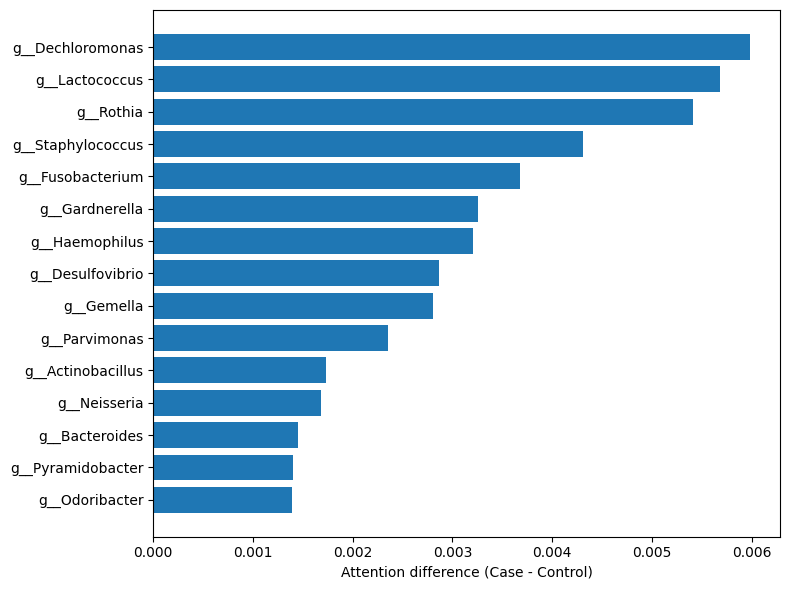

In [ ]:
import matplotlib.pyplot as plt

top = comparison.sort_values(
    "Difference",
    ascending=False
).head(15)

plt.figure(figsize=(8,6))
plt.barh(
    top.index,
    top["Difference"]
)
plt.gca().invert_yaxis()
plt.xlabel("Attention difference (Case - Control)")
plt.tight_layout()
plt.show()